# Janome による日本語の形態素解析

## テキストファイルの読み込み

In [1]:
# テキストファイルの読み込み
src = "sangetsuki.txt"              # 同じフォルダにあるテキストファイルの名前
f = open(src, encoding="utf_8_sig") # 文字コードが UTF BOM付き でない場合は，utf_8_sig を書き換える
text = f.read()
f.close()

text

'山月記\n中島敦\n\n\n\n\u3000隴西の李徴は博学才穎、天宝の末年、若くして名を虎榜に連ね、ついで江南尉に補せられたが、性、狷介、自ら恃むところ頗る厚く、賤吏に甘んずるを潔しとしなかった。いくばくもなく官を退いた後は、故山、虢略に帰臥し、人と交を絶って、ひたすら詩作に耽った。下吏となって長く膝を俗悪な大官の前に屈するよりは、詩家としての名を死後百年に遺そうとしたのである。しかし、文名は容易に揚らず、生活は日を逐うて苦しくなる。李徴は漸く焦躁に駆られて来た。この頃からその容貌も峭刻となり、肉落ち骨秀で、眼光のみ徒らに炯々として、曾て進士に登第した頃の豊頬の美少年の俤は、何処に求めようもない。数年の後、貧窮に堪えず、妻子の衣食のために遂に節を屈して、再び東へ赴き、一地方官吏の職を奉ずることになった。一方、これは、己の詩業に半ば絶望したためでもある。曾ての同輩は既に遥か高位に進み、彼が昔、鈍物として歯牙にもかけなかったその連中の下命を拝さねばならぬことが、往年の儁才李徴の自尊心を如何に傷けたかは、想像に難くない。彼は怏々として楽しまず、狂悖の性は愈々抑え難くなった。一年の後、公用で旅に出、汝水のほとりに宿った時、遂に発狂した。或夜半、急に顔色を変えて寝床から起上ると、何か訳の分らぬことを叫びつつそのまま下にとび下りて、闇の中へ駈出した。彼は二度と戻って来なかった。附近の山野を捜索しても、何の手掛りもない。その後李徴がどうなったかを知る者は、誰もなかった。\n\u3000翌年、監察御史、陳郡の袁傪という者、勅命を奉じて嶺南に使し、途に商於の地に宿った。次の朝未だ暗い中に出発しようとしたところ、駅吏が言うことに、これから先の道に人喰虎が出る故、旅人は白昼でなければ、通れない。今はまだ朝が早いから、今少し待たれたが宜しいでしょうと。袁傪は、しかし、供廻りの多勢なのを恃み、駅吏の言葉を斥けて、出発した。残月の光をたよりに林中の草地を通って行った時、果して一匹の猛虎が叢の中から躍り出た。虎は、あわや袁傪に躍りかかるかと見えたが、忽ち身を飜して、元の叢に隠れた。叢の中から人間の声で「あぶないところだった」と繰返し呟くのが聞えた。その声に袁傪は聞き憶えがあった。驚懼の中にも、彼は咄嗟に思いあたって、叫んだ。「その声は、我が友、李徴子ではないか？」袁傪は李徴と同年に進士の第に

## 形態素解析

In [2]:
# 記号を取り除き，複合名詞は1つの名詞にまとめて，形態素解析を行う
from janome.tokenizer import Tokenizer
from janome.analyzer import Analyzer
from janome.tokenfilter import *
tokenizer = Tokenizer()
token_filters = [CompoundNounFilter(), POSStopFilter('記号')]
a = Analyzer(tokenizer=tokenizer, token_filters=token_filters)

# 結果を表の形にして表示する
tab = [[t.surface] + t.part_of_speech.split(',') +
       [t.infl_type, t.infl_form, t.base_form, t.reading, t.phonetic]
       for t in a.analyze(text)]

import pandas as pd
tokens = pd.DataFrame(tab)
tokens.columns = [
    '表層形', '品詞', '品詞細分類1', '品詞細分類2', '品詞細分類3',
    '活用型', '活用形', '原形', '読み', '発音'
    ]
#tokens.to_csv('tokens.csv', index=False, encoding='utf_8_sig')

tokens

,表層形,品詞,品詞細分類1,品詞細分類2,品詞細分類3,活用型,活用形,原形,読み,発音
0,山月記,名詞,複合,*,*,*,*,山月記,ヤマツキキ,ヤマツキキ
1,中島敦,名詞,複合,*,*,*,*,中島敦,ナカジマアツシ,ナカジマアツシ
2,隴西,名詞,一般,*,*,*,*,隴西,*,*
3,の,助詞,連体化,*,*,*,*,の,ノ,ノ
4,李徴,名詞,複合,*,*,*,*,李徴,リシルシ,リシルシ
...,...,...,...,...,...,...,...,...,...,...
3406,は,助詞,係助詞,*,*,*,*,は,ハ,ワ
3407,ボランティア,名詞,一般,*,*,*,*,ボランティア,ボランティア,ボランティア
3408,の,助詞,連体化,*,*,*,*,の,ノ,ノ
3409,皆さん,名詞,一般,*,*,*,*,皆さん,ミナサン,ミナサン


# 日本語ワードクラウドの生成

In [3]:
# 名詞, 動詞, 形容詞に限定して単語の(原形の)リストを作る
ind_filters = [CompoundNounFilter(), POSKeepFilter(['名詞', '動詞', '形容詞'])]
a2 = Analyzer(tokenizer=tokenizer, token_filters=ind_filters)
words_list = [ t.base_form for t in a2.analyze(text)]

words_list

['山月記',
 '中島敦',
 '隴西',
 '李徴',
 '博学才穎',
 '天宝',
 '末年',
 '名',
 '虎榜',
 '連ねる',
 '江南尉',
 '補する',
 'られる',
 '性',
 '狷介',
 '自ら恃むところ',
 '厚い',
 '賤吏',
 '甘んずる',
 '潔い',
 'する',
 'ない',
 '官',
 '退く',
 '後',
 '故山',
 '虢略',
 '帰臥',
 'する',
 '人',
 '交',
 '絶つ',
 '詩作',
 '耽る',
 '吏',
 'なる',
 '長い',
 '膝',
 '俗悪',
 '大官',
 '前',
 '屈する',
 '詩家',
 '名',
 '死後百年',
 '遺す',
 'する',
 'の',
 '文名',
 '容易',
 '揚る',
 '生活',
 '日',
 '逐う',
 '苦しい',
 'なる',
 '李徴',
 '焦躁',
 '駆る',
 'れる',
 '来る',
 '頃',
 '容貌',
 '峭刻',
 'なる',
 '肉落ち骨',
 '秀でる',
 '眼光',
 '徒ら',
 '炯々',
 '曾',
 '進士',
 '登',
 'する',
 '頃',
 '豊頬',
 '美少年',
 '俤',
 '何処',
 '求める',
 'よう',
 'ない',
 '数年',
 '後',
 '貧窮',
 '堪える',
 '妻子',
 '衣食',
 'ため',
 '節',
 '屈す',
 '東',
 '赴く',
 '一地方官吏',
 '職',
 '奉ずる',
 'こと',
 'なる',
 'これ',
 '己',
 '詩業',
 '半ば絶望',
 'する',
 'ため',
 'ある',
 '曾',
 '同輩',
 '遥か高位',
 '進む',
 '彼',
 '昔',
 '鈍物',
 '歯牙',
 'かける',
 '連中',
 '下命',
 '拝',
 'する',
 'なる',
 'こと',
 '往年',
 '儁才李徴',
 '自尊心',
 '如何',
 '傷けた',
 '想像',
 '難い',
 '彼',
 '怏々',
 '楽しむ',
 '狂',
 '悖る',
 '性',
 '抑える',
 '難い',
 'なる',
 '一年',
 '後',
 '公用',
 '旅',
 '出る',
 '汝水

In [4]:
# 一部の頻出語を除去する
rm_words = [
    "ある", "いる", "する", "せる", "なる", "これ", "それ", "あれ", "どれ",
    "この", "その", "あの", "どの", "もの", "こと", "よう", "れる", "の",
    "ない"
    ]
for rw in rm_words:
    words_list = [w for w in words_list if w!=rw]

# 単語のリストを一つのテキスト(文字列)にまとめる
words = '\n'.join(words_list)

print(words)

山月記
中島敦
隴西
李徴
博学才穎
天宝
末年
名
虎榜
連ねる
江南尉
補する
られる
性
狷介
自ら恃むところ
厚い
賤吏
甘んずる
潔い
官
退く
後
故山
虢略
帰臥
人
交
絶つ
詩作
耽る
吏
長い
膝
俗悪
大官
前
屈する
詩家
名
死後百年
遺す
文名
容易
揚る
生活
日
逐う
苦しい
李徴
焦躁
駆る
来る
頃
容貌
峭刻
肉落ち骨
秀でる
眼光
徒ら
炯々
曾
進士
登
頃
豊頬
美少年
俤
何処
求める
数年
後
貧窮
堪える
妻子
衣食
ため
節
屈す
東
赴く
一地方官吏
職
奉ずる
己
詩業
半ば絶望
ため
曾
同輩
遥か高位
進む
彼
昔
鈍物
歯牙
かける
連中
下命
拝
往年
儁才李徴
自尊心
如何
傷けた
想像
難い
彼
怏々
楽しむ
狂
悖る
性
抑える
難い
一年
後
公用
旅
出る
汝水
ほとり
宿る
時
発狂
夜半
急
顔色
変える
寝床
起
上る
何
訳
分る
叫ぶ
下
とぶ
下りる
闇
中
駈る
出す
彼
戻る
来る
附近
山野
捜索
何
手掛り
その後李徴
知る
者
誰
翌年
監察
史
陳郡
袁傪
者
勅命
奉じる
嶺南
使
途
商於
地
宿る
次
朝
暗い
中
出発
ところ
駅吏
言う
先
道
人喰虎
出る
故
旅人
白昼
通れる
今
朝
早い
今
待つ
宜しい
袁傪
供廻り
多勢
恃
みる
駅吏
言葉
斥ける
出発
残月
光
たより
林中
草地
通る
行く
時
一匹
猛虎
叢
中
躍り出る
虎
袁傪
躍りかかる
見える
身
飜
元
叢
隠れる
叢
中
人間
声
あぶない
ところ
繰返し
呟く
聞える
声
袁傪
聞く
憶える
驚懼
中
彼
咄嗟
思いあたる
叫ぶ
声
友
李徴子
袁傪
李徴
同年
進士
登る
友人
少い
李徴
親しい
友
温和
袁傪
性格
峻峭
李徴
性情
衝突
ため
叢
中
返辞
無い
しのぶ
泣き
思う
微か
声
洩れる
低い
声
答える
自分
隴西
李徴
袁傪
恐怖
忘れる
馬
下りる
叢
近づく
懐かしい
げ
久闊
叙
叢
出る
来る
問う
李徴
声
答える
言う
自分
異類
身
故人
前
あさましい
姿
さらせる
自分
姿
現す
君
畏怖嫌厭
情
起す
決る
今
図る
故人
遇う
得る
愧赧
念
忘れる
程
懐かしい
いい
醜悪
今
外形
厭う
曾
君
友李徴
自分
話
交す
くれる

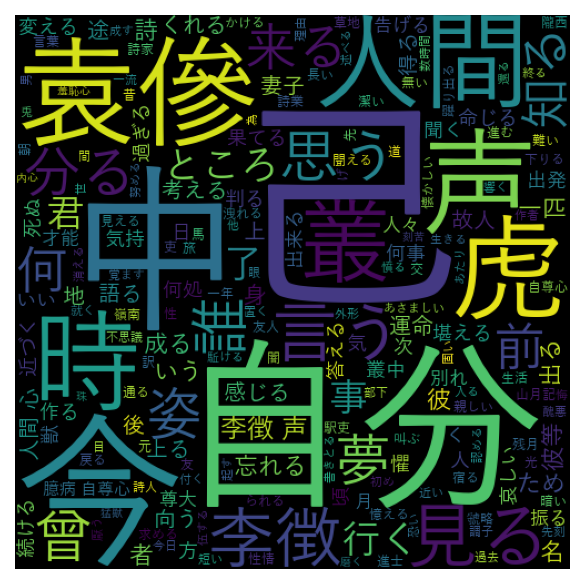

In [5]:
# ワードクラウドの生成表示
from wordcloud import WordCloud
import matplotlib.pyplot as plt
wc = WordCloud(font_path="/c:/Windows/Fonts/YuGothM.ttc", width=500, height=500)
wc.generate(words)
plt.figure(dpi=150)     # dpi の数字を大きくすると，大きく表示
plt.imshow(wc)
plt.axis("off")         # 軸目盛りの非表示
plt.show()